# EXPERIMENTOS TFG #

En este documento se recogen los experimentos del TFG Métodos de descenso por coordenadas realizado por Miguel Ángel Sevila Pérez

## PAQUETES ##

In [18]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.optimize as op
import random
from matplotlib.animation import FuncAnimation

In [19]:
#%matplotlib tk

In [20]:
%matplotlib inline

## ALGORITMOS Y FUNCIONES ##

### Búsqueda de tamaño de paso ###

In [21]:
#BACKTRACKING (BACK)
def backtracking(f,xk,p,alpha=1,rho=0.5,c=10**(-4)):
    alfa=alpha
    while f(xk+alfa*p)>f(xk)+c*alfa*(-np.dot(p,p)):
        alfa=alfa*rho
    return alfa

#NO MONÓTONO POR MÁXIMO DE ITERACIONES PREVIAS (MIP)
def maximo(f,xk,p,maximof,alpha=1,rho=0.5,c=10**(-4)):
    alfa=alpha
    while f(xk+alfa*p)>maximof+c*alfa*(-np.dot(p,p)):
        alfa=alfa*rho
    return alfa

#NO MONÓTONO POR COMBINACIÓN CONVEXA (CC)
def combconv(f,xk,p,R,alpha=1,rho=0.5,c=10**(-4)):
    alfa=alpha
    while f(xk+alfa*p)>R+c*alfa*(-np.dot(p,p)):
        alfa=alfa*rho
    return alfa

### Métodos de descenso ###

In [22]:
#MÉTODO DE DESCENSO POR COORDENADAS ALEATORIZADO
def dca(f,g,x0,alpha=0.1,metodo='backtracking',M=5,lam=0.25,maxit=10000,tol=10**(-3),m=10):
    n=len(x0)
    iteraciones=np.zeros((maxit+1,n))
    iteraciones[0]=x0
    valores=np.zeros(maxit+1)
    valores[0]=f(x0)
    xk=x0
    cont=0
    continuar=True
    while cont<maxit and continuar:
        ik=random.randint(0,n-1)
        p=np.zeros(n)
        p[ik]=-g(xk)[ik]
        if metodo=='backtracking':
            alfa=backtracking(f,xk,p,alpha=alpha)
        if metodo=='maximo':
            maximof=max(valores[max(cont-M,0):cont+1])
            alfa=maximo(f,xk,p,maximof,alpha=alpha)
        if metodo=='combconv':
            if cont==0:
                R=valores[0]
            else:
                R=(1-lam)*R+lam*valores[cont]
            alfa=combconv(f,xk,p,R,alpha=alpha)
        xk=xk+alfa*p
        cont+=1
        iteraciones[cont]=xk
        valores[cont]=f(xk)
        if cont>=m:
            if la.norm(iteraciones[cont]-iteraciones[cont-m])<tol:
                continuar=False
    iteraciones=iteraciones[0:cont+1]
    valores=valores[0:cont+1]
    return iteraciones,valores,len(valores)-1

#MÉTODO DE DESCENSO POR COORDENADAS ALEATORIZADO QUE APROXIMA AL MÍNIMO MÁS CERCANO (EXPERIMENTO 1)
def dcae(f,g,x0,alpha=0.1,metodo='backtracking',M=5,lam=0.25,maxit=1000,tol=10**(-3),m=10):
    n=len(x0)
    iteraciones=np.zeros((maxit+1,n))
    iteraciones[0]=x0
    valores=np.zeros(maxit+1)
    valores[0]=f(x0)
    xk=x0
    cont=0
    continuar=True
    while cont<maxit and continuar:
        ik=random.randint(0,n-1)
        p=np.zeros(n)
        p[ik]=-g(xk)[ik]
        if metodo=='backtracking':
            alfa=backtracking(f,xk,p,alpha=alpha)
        if metodo=='maximo':
            maximof=max(valores[max(cont-M,0):cont+1])
            alfa=maximo(f,xk,p,maximof,alpha=alpha)
        if metodo=='combconv':
            if cont==0:
                R=valores[0]
            else:
                R=(1-lam)*R+lam*valores[cont]
            alfa=combconv(f,xk,p,R,alpha=alpha)
        xk=xk+alfa*p
        cont+=1
        iteraciones[cont]=xk
        valores[cont]=f(xk)
        if cont>=m:
            if la.norm(iteraciones[cont]-iteraciones[cont-m])<tol:
                continuar=False
    iteraciones[cont]=np.round(iteraciones[cont])
    iteraciones=iteraciones[0:cont+1]
    valores[cont]=f(iteraciones[cont])
    valores=valores[0:cont+1]
    return iteraciones,valores,len(valores)-1

#MÉTODO DEL GRADIENTE
def grad(f,g,x0,it=100,paso=1,metodo='back',M=2,lam=0.5):
    n=len(x0)
    iteraciones=np.zeros((it+1,n))
    iteraciones[0]=x0
    if n==1:
        xk=x0[0]
    else:
        xk=x0
    valores=np.zeros(it+1)
    valores[0]=f(xk)
    for i in range(it):
        p=-g(xk)
        if metodo=='back':
            alfa=backtracking(f,xk,p,alpha=paso)
        if metodo=='nm1':
            maximof=max(valores[max(i-M,0):i+1])
            alfa=maximo(f,xk,p,maximof,alpha=paso)
        if metodo=='nm2':
            if i==0:
                R=valores[0]
            else:
                R=(1-lam)*R+lam*valores[i]
            alfa=combconv(f,xk,p,R,alpha=paso)
        xk=xk+alfa*p
        iteraciones[i+1]=xk
        valores[i+1]=f(xk)
    return iteraciones

### Funciones auxiliares ###

In [23]:
def simetrica(n):
    matriz=np.random.randint(-5,5,size=(n,n))
    sim=(matriz+matriz.T)
    return sim

## FIGURA DESCENSO MÁS RÁPIDO ##

In [24]:
def f(x):
    return 4*x[0]**2-x[0]*x[1]+2*x[1]**2

def g(x):
    return np.array([8*x[0]-x[1],4*x[1]-x[0]])

In [25]:
gradiente=grad(f,g,[0.7,0.8],it=20)

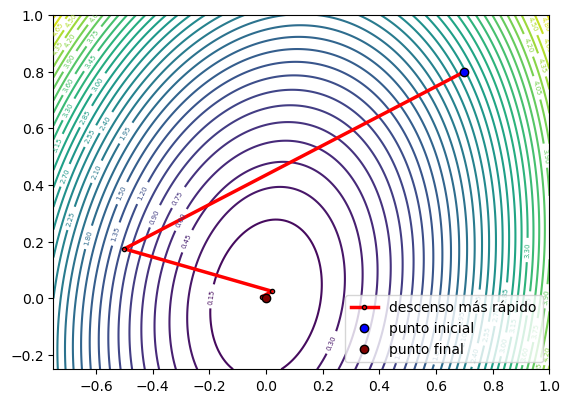

In [26]:
[X,Y]=np.meshgrid(np.linspace(-0.75,1,200),np.linspace(-0.25,1,200))
Z=f([X,Y])

plt.figure()
con=plt.contour(X,Y,Z,40,cmap='viridis')
plt.clabel(con,fontsize=5)

plt.plot(gradiente[:,0],gradiente[:,1],linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='descenso más rápido')
plt.plot(0.7,0.8,'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(gradiente[20][0],gradiente[20][1],'o',color='maroon',markeredgecolor='black',label='punto final')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10,loc='lower right')
plt.xlim((-0.75,1))
plt.ylim((-0.25,1))
plt.axis('scaled') 

plt.savefig('tfg_fig_mdmr.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

## EJEMPLO CONVERGENCIA ##

In [27]:
def f(x):
    return np.log(1+np.exp(x))

def g(x):
    return (np.exp(x))/(1+np.exp(x))

In [28]:
gradiente2=grad(f,g,[1],it=10000)

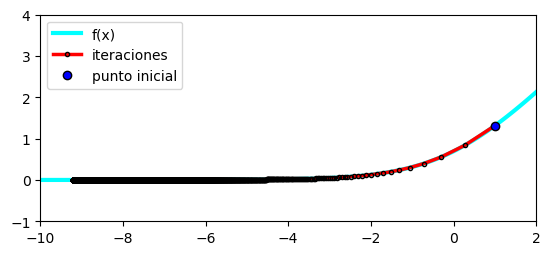

In [29]:
xr=np.linspace(-10,2,120)

plt.figure()

plt.plot(xr,f(xr),linewidth=3,linestyle='solid',color='cyan',label='f(x)')
plt.plot(gradiente2[:,0],f(gradiente2[:,0]),linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='iteraciones')
plt.plot(1,f([1]),'o',color='blue',label='punto inicial',markeredgecolor='black')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10,loc='upper left')
plt.xlim((-10,2))
plt.ylim((-1,4))
plt.gca().set_aspect('equal')

plt.savefig('tfg_ej_conv.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

## EJEMPLOS DESCENSO POR COORDENADAS ALEATORIZADO ##

In [30]:
def f(x):
    return 8*x[0]**2-2*x[0]*x[1]+x[1]**2-4*x[0]**3+(1/2)*x[0]**4

def g(x):
    return np.array([16*x[0]-2*x[1]-12*x[0]**2+2*x[0]**3,2*x[1]-2*x[0]])

### Usando backtracking ###

In [31]:
random.seed(1)
aleatorio1=dca(f,g,[1,6],alpha=0.5,tol=10**(-7))
random.seed(12)
aleatorio2=dca(f,g,[1,6],alpha=0.5,tol=10**(-7))

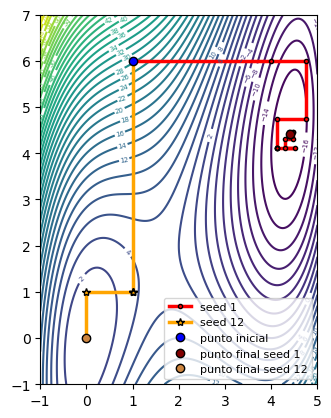

Iteraciones backtracking seed 1: 88
Iteraciones backtracking seed 12: 15


In [32]:
[X,Y]=np.meshgrid(np.linspace(-1,5,200),np.linspace(-1,7,200))
Z=f([X,Y])

plt.figure()
con=plt.contour(X,Y,Z,50,cmap='viridis')
plt.clabel(con,fontsize=5)

plt.plot(aleatorio1[0][:,0],aleatorio1[0][:,1],linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='seed 1')
plt.plot(aleatorio2[0][:,0],aleatorio2[0][:,1],linewidth=2.5,linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='seed 12')
plt.plot(1,6,'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(aleatorio1[0][aleatorio1[2],0],aleatorio1[0][aleatorio1[2],1],'o',color='maroon',markeredgecolor='black',label='punto final seed 1')
plt.plot(aleatorio2[0][aleatorio2[2],0],aleatorio2[0][aleatorio2[2],1],'o',color='peru',markeredgecolor='black',label='punto final seed 12')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=8,loc='lower right')
plt.xlim((-1,5))
plt.ylim((-1,7))
plt.axis('scaled') 

plt.savefig('tfg_ej_back.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

print('Iteraciones backtracking seed 1:',aleatorio1[2])
print('Iteraciones backtracking seed 12:',aleatorio2[2])

### Usando máximo de iteraciones previas ###

In [33]:
random.seed(1)
aleatoriomax1=dca(f,g,[1,6],alpha=0.5,tol=10**(-7),metodo='maximo')
random.seed(12)
aleatoriomax2=dca(f,g,[1,6],alpha=0.5,tol=10**(-7),metodo='maximo')

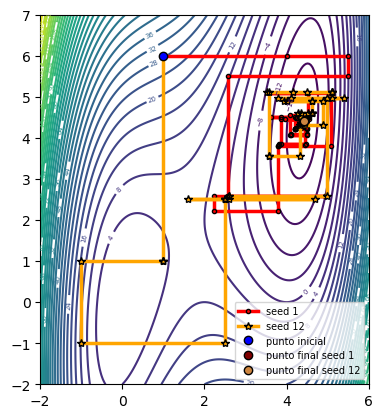

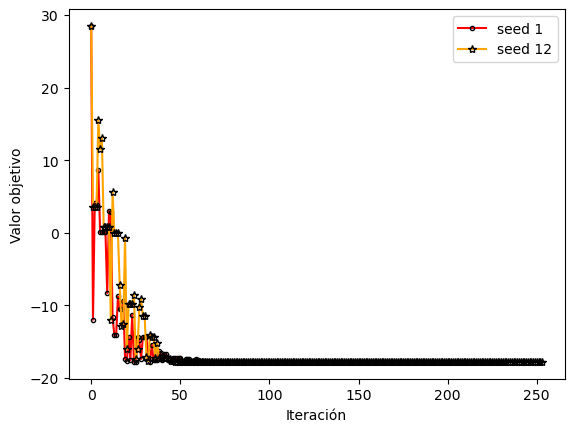

Iteraciones máximo seed 1: 233
Iteraciones máximo seed 12: 254


In [34]:
[X,Y]=np.meshgrid(np.linspace(-2,6,200),np.linspace(-2,7,200))
Z=f([X,Y])

plt.figure()
con=plt.contour(X,Y,Z,50,cmap='viridis')
plt.clabel(con,fontsize=5)

plt.plot(aleatoriomax1[0][:,0],aleatoriomax1[0][:,1],linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='seed 1')
plt.plot(aleatoriomax2[0][:,0],aleatoriomax2[0][:,1],linewidth=2.5,linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='seed 12')
plt.plot(1,6,'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(aleatoriomax1[0][aleatoriomax1[2],0],aleatoriomax1[0][aleatoriomax1[2],1],'o',color='maroon',markeredgecolor='black',label='punto final seed 1')
plt.plot(aleatoriomax2[0][aleatoriomax2[2],0],aleatoriomax2[0][aleatoriomax2[2],1],'o',color='peru',markeredgecolor='black',label='punto final seed 12')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=7,loc='lower right')
plt.xlim((-2,6))
plt.ylim((-2,7))
plt.axis('scaled') 

plt.savefig('tfg_ej_mip.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

xr1=np.linspace(0,aleatoriomax1[2]-1,aleatoriomax1[2],dtype="int")
xr2=np.linspace(0,aleatoriomax2[2]-1,aleatoriomax2[2],dtype="int")
plt.figure()
plt.plot(xr1,aleatoriomax1[1][xr1],linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='seed 1')
plt.plot(xr2,aleatoriomax2[1][xr2],linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='seed 12')
plt.xlabel('Iteración',fontsize=10)
plt.ylabel('Valor objetivo',fontsize=10)
plt.legend(fontsize=10,loc='upper right')


plt.savefig('tfg_ej_mipvalues.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

print('Iteraciones máximo seed 1:',aleatoriomax1[2])
print('Iteraciones máximo seed 12:',aleatoriomax2[2])

### Usando combinación convexa ###

In [35]:
random.seed(1)
aleatoriocc1=dca(f,g,[1,6],alpha=0.5,tol=10**(-7),metodo='combconv')
random.seed(12)
aleatoriocc2=dca(f,g,[1,6],alpha=0.5,tol=10**(-7),metodo='combconv')

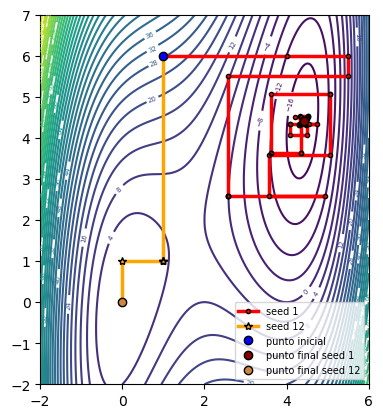

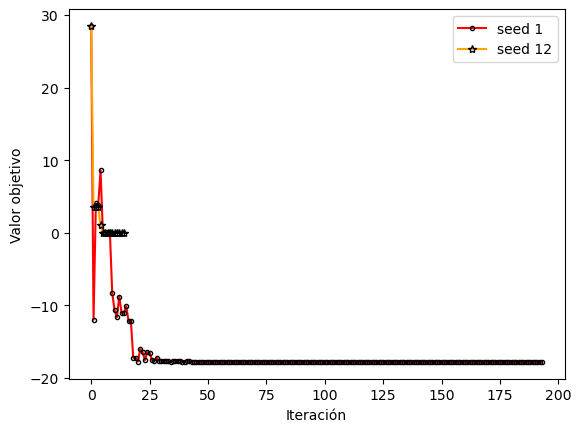

Iteraciones combinación convexa seed 1: 194
Iteraciones combinación convexa seed 12: 15


In [36]:
[X,Y]=np.meshgrid(np.linspace(-2,6,200),np.linspace(-2,7,200))
Z=f([X,Y])

plt.figure()
con=plt.contour(X,Y,Z,50,cmap='viridis')
plt.clabel(con,fontsize=5)

plt.plot(aleatoriocc1[0][:,0],aleatoriocc1[0][:,1],linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='seed 1')
plt.plot(aleatoriocc2[0][:,0],aleatoriocc2[0][:,1],linewidth=2.5,linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='seed 12')
plt.plot(1,6,'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(aleatoriocc1[0][aleatoriocc1[2],0],aleatoriocc1[0][aleatoriocc1[2],1],'o',color='maroon',markeredgecolor='black',label='punto final seed 1')
plt.plot(aleatoriocc2[0][aleatoriocc2[2],0],aleatoriocc2[0][aleatoriocc2[2],1],'o',color='peru',markeredgecolor='black',label='punto final seed 12')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=7,loc='lower right')
plt.xlim((-2,6))
plt.ylim((-2,7))
plt.axis('scaled') 

plt.savefig('tfg_ej_cc.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

xr1=np.linspace(0,aleatoriocc1[2]-1,aleatoriocc1[2],dtype="int")
xr2=np.linspace(0,aleatoriocc2[2]-1,aleatoriocc2[2],dtype="int")
plt.figure()
plt.plot(xr1,aleatoriocc1[1][xr1],linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='seed 1')
plt.plot(xr2,aleatoriocc2[1][xr2],linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='seed 12')
plt.xlabel('Iteración',fontsize=10)
plt.ylabel('Valor objetivo',fontsize=10)
plt.legend(fontsize=10,loc='upper right')

plt.savefig('tfg_ej_ccvalues.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

print('Iteraciones combinación convexa seed 1:',aleatoriocc1[2])
print('Iteraciones combinación convexa seed 12:',aleatoriocc2[2])

## EXPERIMENTO 1 ##

In [37]:
dim=2

In [38]:
def f(x):
    sumatorio=0
    for i in range(dim):
        sumatorio+=x[i]**2-10*np.cos(2*np.pi*x[i])
    return 10*dim+sumatorio

def g(x):
    gradiente=np.zeros(dim)
    for i in range(dim):
        gradiente[i]=20*np.pi*np.sin(2*np.pi*x[i])+2*x[i]
    return gradiente

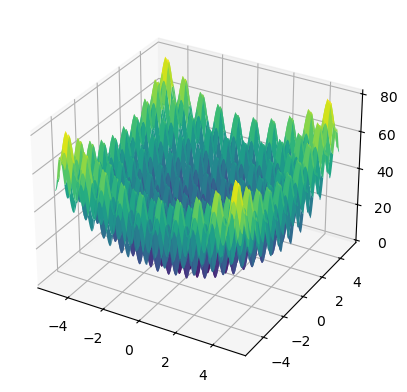

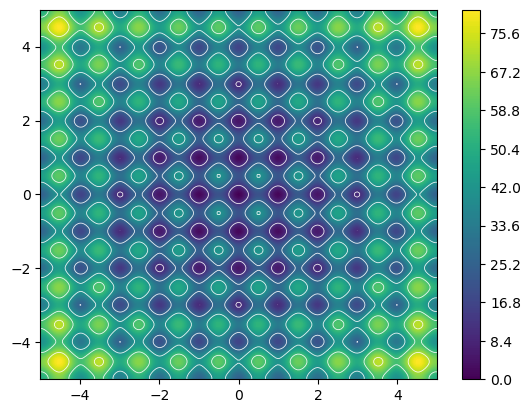

In [39]:
[X,Y]=np.meshgrid(np.linspace(-5,5,200),np.linspace(-5,5,200))
Z=f([X,Y])

plt.figure()
ejes=plt.axes(projection='3d')
ejes.plot_surface(X,Y,Z,cmap='viridis')

plt.savefig('tfg_fig_rastrigin.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.figure()
plt.contourf(X,Y,Z,200)
plt.colorbar()
contour_levels = np.arange(10, 80, 15) 
plt.contour(X, Y, Z, levels=contour_levels, colors='white', linewidths=0.6, alpha=0.9)

plt.savefig('tfg_fig_rastrigin2.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

### Un caso particular ###

In [40]:
semilla=100
np.random.seed(semilla)
x0=np.random.uniform(-4,4,dim)
print(x0)
random.seed(semilla)
experimento31=dca(f,g,x0,metodo='backtracking')
random.seed(semilla)
experimento32=dca(f,g,x0,metodo='maximo')
random.seed(semilla)
experimento33=dca(f,g,x0,metodo='combconv')

[ 0.34723953 -1.77304492]


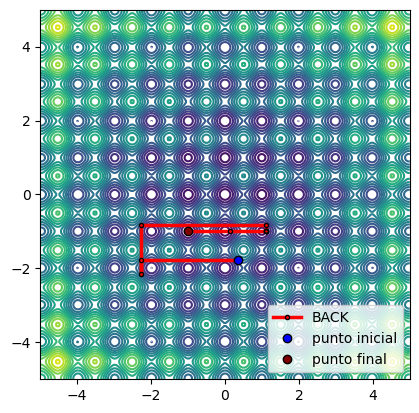

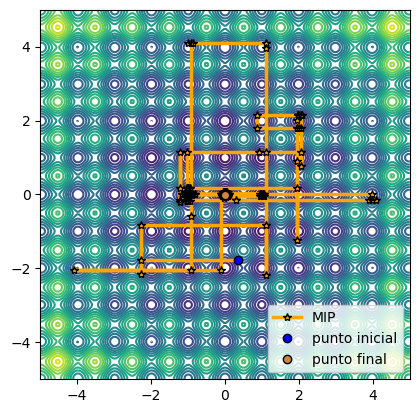

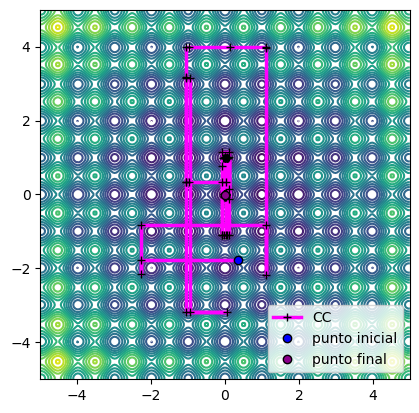

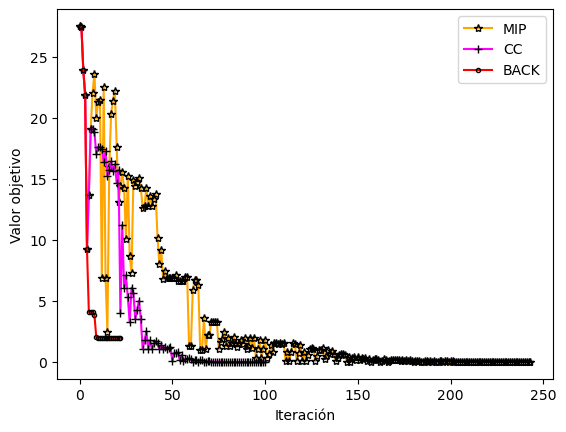

BACK: Punto alcanzado: [-0.99495849 -0.99495864] Valor de f alcanzado: 1.9899181141911697 Número de iteraciones 23
MIP: Punto alcanzado: [ 0.00155768 -0.00510147] Valor de f alcanzado: 0.005644073976803554 Número de iteraciones 244
CC: Punto alcanzado: [-0.00025911 -0.00301694] Valor de f alcanzado: 0.0018190144746057513 Número de iteraciones 101


In [41]:
[X,Y]=np.meshgrid(np.linspace(-5,5,200),np.linspace(-5,5,200))
Z=f([X,Y])

#Figura BACK

plt.figure()
con=plt.contour(X,Y,Z,20,cmap='viridis')
#plt.clabel(con,fontsize=5)

plt.plot(experimento31[0][:,0],experimento31[0][:,1],linewidth=2.5,linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='BACK')
plt.plot(x0[0],x0[1],'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(experimento31[0][experimento31[2],0],experimento31[0][experimento31[2],1],'o',color='maroon',markeredgecolor='black',label='punto final')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10,loc='lower right')
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.axis('scaled') 

plt.savefig('tfg_ex_cp_back.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

#Figura MIP

plt.figure()
con=plt.contour(X,Y,Z,20,cmap='viridis')
#plt.clabel(con,fontsize=5)

plt.plot(experimento32[0][:,0],experimento32[0][:,1],linewidth=2.5,linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='MIP')
plt.plot(x0[0],x0[1],'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(experimento32[0][experimento32[2],0],experimento32[0][experimento32[2],1],'o',color='peru',markeredgecolor='black',label='punto final')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10,loc='lower right')
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.axis('scaled') 

plt.savefig('tfg_ex_cp_mip.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

#Figura CC

plt.figure()
con=plt.contour(X,Y,Z,20,cmap='viridis')
#plt.clabel(con,fontsize=5)

plt.plot(experimento33[0][:,0],experimento33[0][:,1],linewidth=2.5,linestyle='solid',color='magenta',marker='+', markerfacecolor='none', markeredgecolor='black',label='CC')
plt.plot(x0[0],x0[1],'o',color='blue',label='punto inicial',markeredgecolor='black')
plt.plot(experimento33[0][experimento33[2],0],experimento33[0][experimento33[2],1],'o',color='darkmagenta',markeredgecolor='black',label='punto final')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10,loc='lower right')
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.axis('scaled') 

plt.savefig('tfg_ex_cp_cc.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

#Figura valores

xr1=np.linspace(0,experimento31[2]-1,experimento31[2],dtype="int")
xr2=np.linspace(0,experimento32[2]-1,experimento32[2],dtype="int")
xr3=np.linspace(0,experimento33[2]-1,experimento33[2],dtype="int")
plt.figure()
plt.plot(xr2,experimento32[1][xr2],linestyle='solid',color='orange',marker='*', markerfacecolor='none', markeredgecolor='black',label='MIP')
plt.plot(xr3,experimento33[1][xr3],linestyle='solid',color='magenta',marker='+', markerfacecolor='none', markeredgecolor='black',label='CC')
plt.plot(xr1,experimento31[1][xr1],linestyle='solid',color='red',marker='.', markerfacecolor='none', markeredgecolor='black',label='BACK')
plt.xlabel('Iteración',fontsize=10)
plt.ylabel('Valor objetivo',fontsize=10)
plt.legend(fontsize=10,loc='upper right')


plt.savefig('tfg_ex_cp_values.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

print('BACK: Punto alcanzado:',experimento31[0][experimento31[2]],'Valor de f alcanzado:',experimento31[1][experimento31[2]],'Número de iteraciones',experimento31[2])
print('MIP: Punto alcanzado:',experimento32[0][experimento32[2]],'Valor de f alcanzado:',experimento32[1][experimento32[2]],'Número de iteraciones',experimento32[2])
print('CC: Punto alcanzado:',experimento33[0][experimento33[2]],'Valor de f alcanzado:',experimento33[1][experimento33[2]],'Número de iteraciones',experimento33[2])

### Test ###

Ejecutamos los tres algoritmos bajo idénticas condiciones (mismas constantes para el método, mismo punto inicial y misma seed para los índices aleatorios) un gran número de veces para ver si en general hay diferencias entre los tres.

In [42]:
numerotest=100
co=np.zeros((10,3))
fila=0
dimensiones=[2,3,5,8,10,12,15,20,25,50]
for k in dimensiones:
    dim=k
    resultados=np.zeros((numerotest,6))
    for i in range(numerotest):
        np.random.seed(i+28)
        x0=np.random.uniform(-5,5,dim)
        random.seed(i+28)
        mono=dca(f,g,x0)
        random.seed(i+28)
        nomono1=dca(f,g,x0,metodo='maximo')
        random.seed(i+28)
        nomono2=dca(f,g,x0,metodo='combconv')
        resultados[i][0]=mono[1][mono[2]]
        resultados[i][1]=nomono1[1][nomono1[2]]
        resultados[i][2]=nomono2[1][nomono2[2]]
        resultados[i][3]=mono[2]
        resultados[i][4]=nomono1[2]
        resultados[i][5]=nomono2[2]

    monotono=0
    maximos=0
    convexo=0
    for i in range(numerotest):
        if resultados[i][0]<=resultados[i][1] and resultados[i][0]<=resultados[i][2]:
            monotono+=1
        if resultados[i][1]<=resultados[i][0] and resultados[i][1]<=resultados[i][2]:
            maximos+=1
        if resultados[i][2]<=resultados[i][0] and resultados[i][2]<=resultados[i][1]:
            convexo+=1
            
    print('Dimensión:',dim)

    print('Veces que BACK es mejor:',monotono)
    print('Veces que MIP es mejor:',maximos)
    print('Veces que CC es mejor:',convexo)

    print('Número medio iteraciones BACK:',np.mean(resultados[:,3]))
    print('Número medio iteraciones MIP:',np.mean(resultados[:,4]))
    print('Número medio iteraciones CC:',np.mean(resultados[:,5]))

    co[fila]=[monotono,maximos,convexo]
    fila+=1

Dimensión: 2
Veces que BACK es mejor: 15
Veces que MIP es mejor: 37
Veces que CC es mejor: 48
Número medio iteraciones BACK: 21.31
Número medio iteraciones MIP: 223.91
Número medio iteraciones CC: 94.62
Dimensión: 3
Veces que BACK es mejor: 7
Veces que MIP es mejor: 54
Veces que CC es mejor: 39
Número medio iteraciones BACK: 29.17
Número medio iteraciones MIP: 429.57
Número medio iteraciones CC: 149.77
Dimensión: 5
Veces que BACK es mejor: 1
Veces que MIP es mejor: 65
Veces que CC es mejor: 34
Número medio iteraciones BACK: 44.13
Número medio iteraciones MIP: 799.68
Número medio iteraciones CC: 260.83
Dimensión: 8
Veces que BACK es mejor: 0
Veces que MIP es mejor: 71
Veces que CC es mejor: 29
Número medio iteraciones BACK: 64.75
Número medio iteraciones MIP: 1330.7
Número medio iteraciones CC: 440.13
Dimensión: 10
Veces que BACK es mejor: 0
Veces que MIP es mejor: 78
Veces que CC es mejor: 22
Número medio iteraciones BACK: 77.45
Número medio iteraciones MIP: 1705.61
Número medio iterac

### Comparación por dimensión y Performance profile para n=2 ###

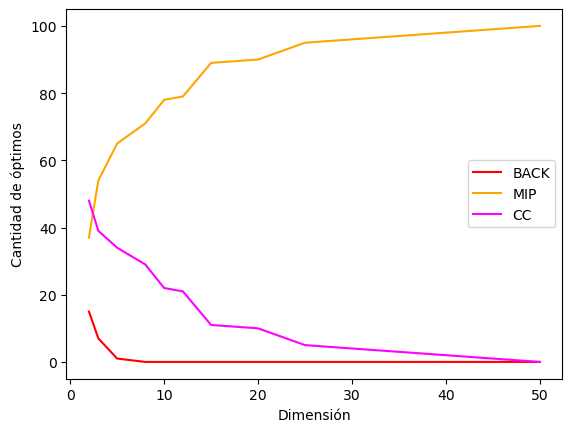

In [43]:
plt.figure()

plt.plot(dimensiones,co[:,0],linestyle='solid',color='red',label='BACK')
plt.plot(dimensiones,co[:,1],linestyle='solid',color='orange',label='MIP')
plt.plot(dimensiones,co[:,2],linestyle='solid',color='magenta',label='CC')
plt.legend(fontsize=10,loc='center right')
plt.xlabel('Dimensión',fontsize=10)
plt.ylabel('Cantidad de óptimos',fontsize=10)

plt.savefig('tfg_ex1_optimos.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

In [44]:
numerotest=100
resultados=np.zeros((numerotest,6))
dim=2
for i in range(numerotest):
    np.random.seed(i+28)
    x0=np.random.uniform(-5,5,dim)
    random.seed(i+28)
    mono=dca(f,g,x0)
    random.seed(i+28)
    nomono1=dca(f,g,x0,metodo='maximo')
    random.seed(i+28)
    nomono2=dca(f,g,x0,metodo='combconv')
    resultados[i][0]=mono[1][mono[2]]
    resultados[i][1]=nomono1[1][nomono1[2]]
    resultados[i][2]=nomono2[1][nomono2[2]]
    resultados[i][3]=mono[2]
    resultados[i][4]=nomono1[2]
    resultados[i][5]=nomono2[2]

monotono=0
maximos=0
convexo=0
for i in range(numerotest):
    if resultados[i][0]<=resultados[i][1] and resultados[i][0]<=resultados[i][2]:
        monotono+=1
    if resultados[i][1]<=resultados[i][0] and resultados[i][1]<=resultados[i][2]:
        maximos+=1
    if resultados[i][2]<=resultados[i][0] and resultados[i][2]<=resultados[i][1]:
        convexo+=1
        
vf=resultados[:,0:3]
bestvalue=np.min(vf, axis=1)
for i in range(numerotest):
    for j in range(3):
        if bestvalue[i]!=0:
            vf[i,j]=vf[i,j]/bestvalue[i]
        else:
            vf[i,j]=10**(10)

            
vfmono=np.sort(vf[:,0])[monotono-1:numerotest]
vfnomono1=np.sort(vf[:,1])[maximos-1:numerotest]
vfnomono2=np.sort(vf[:,2])[convexo-1:numerotest]

propmono=np.linspace(monotono,numerotest,numerotest-monotono+1)/numerotest
propnomono1=np.linspace(maximos,numerotest,numerotest-maximos+1)/numerotest
propnomono2=np.linspace(convexo,numerotest,numerotest-convexo+1)/numerotest

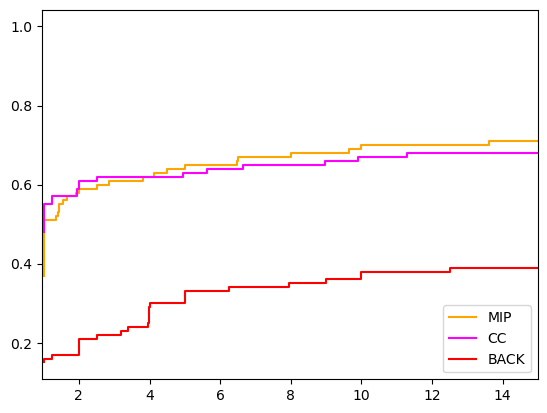

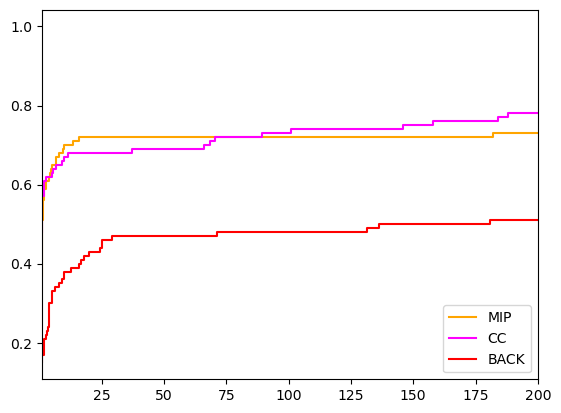

In [45]:
plt.figure()

plt.step(vfnomono1,propnomono1,linestyle='solid',color='orange',label='MIP')
plt.step(vfnomono2,propnomono2,linestyle='solid',color='magenta',label='CC')
plt.step(vfmono,propmono,linestyle='solid',color='red',label='BACK')
plt.xlim(0.95,15)
plt.legend(fontsize=10,loc='lower right')

plt.savefig('tfg_pp1.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

plt.figure()

plt.step(vfnomono1,propnomono1,linestyle='solid',color='orange',label='MIP')
plt.step(vfnomono2,propnomono2,linestyle='solid',color='magenta',label='CC')
plt.step(vfmono,propmono,linestyle='solid',color='red',label='BACK')
plt.xlim(1,200)
plt.legend(fontsize=10,loc='lower right')

plt.savefig('tfg_pp2.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()

### Test aproximando al mínimo mas cercano para n=2 ###

In [46]:
numerotest=100
resultados=np.zeros((numerotest,6))
dim=2
for i in range(numerotest):
    np.random.seed(i+28)
    x0=np.random.uniform(-5,5,dim)
    random.seed(i+28)
    mono=dcae(f,g,x0)
    random.seed(i+28)
    nomono1=dcae(f,g,x0,metodo='maximo')
    random.seed(i+28)
    nomono2=dcae(f,g,x0,metodo='combconv')
    resultados[i][0]=mono[1][mono[2]]
    resultados[i][1]=nomono1[1][nomono1[2]]
    resultados[i][2]=nomono2[1][nomono2[2]]
    resultados[i][3]=mono[2]
    resultados[i][4]=nomono1[2]
    resultados[i][5]=nomono2[2]

In [47]:
monotono=0
maximos=0
convexo=0
for i in range(numerotest):
    if resultados[i][0]<=resultados[i][1] and resultados[i][0]<=resultados[i][2]:
        monotono+=1
    if resultados[i][1]<=resultados[i][0] and resultados[i][1]<=resultados[i][2]:
        maximos+=1
    if resultados[i][2]<=resultados[i][0] and resultados[i][2]<=resultados[i][1]:
        convexo+=1

print('Veces que BACK es mejor:',monotono)
print('Veces que MIP es mejor:',maximos)
print('Veces que CC es mejor:',convexo)

print('Número medio iteraciones BACK:',np.mean(resultados[:,3]))
print('Número medio iteraciones MIP:',np.mean(resultados[:,4]))
print('Número medio iteraciones CC:',np.mean(resultados[:,5]))

Veces que BACK es mejor: 13
Veces que MIP es mejor: 65
Veces que CC es mejor: 58
Número medio iteraciones BACK: 21.31
Número medio iteraciones MIP: 223.91
Número medio iteraciones CC: 94.62


In [48]:
print('Valor óptimo medio BACK:', np.mean(resultados[:,0]))
print('Valor óptimo medio MIP:',np.mean(resultados[:,1]))
print('Valor óptimo medio CC:',np.mean(resultados[:,2]))

Valor óptimo medio BACK: 8.9
Valor óptimo medio MIP: 1.65
Valor óptimo medio CC: 2.02


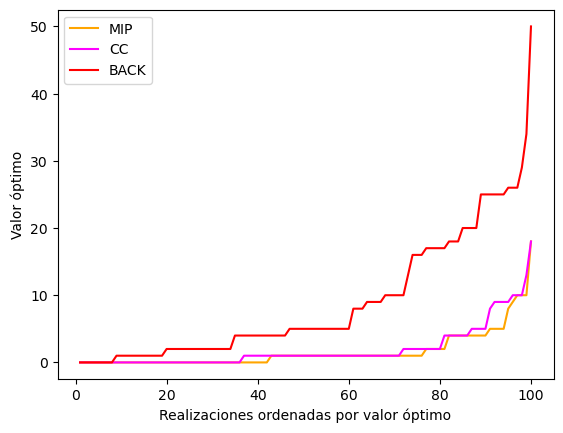

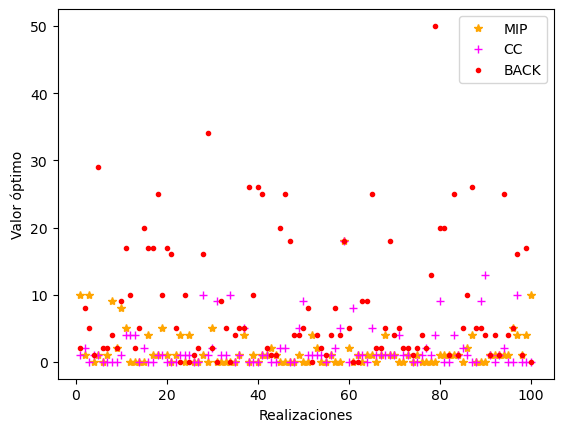

In [49]:
xr=np.linspace(1,100,100)

plt.figure()

plt.plot(xr,np.sort(resultados[:,1]),linestyle='solid',color='orange',label='MIP')
plt.plot(xr,np.sort(resultados[:,2]),linestyle='solid',color='magenta',label='CC')
plt.plot(xr,np.sort(resultados[:,0]),linestyle='solid',color='red',label='BACK')
plt.legend(fontsize=10)
plt.xlabel('Realizaciones ordenadas por valor óptimo',fontsize=10)
plt.ylabel('Valor óptimo',fontsize=10)

plt.savefig('tfg_optimosordenados.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()


plt.figure()

plt.plot(xr,resultados[:,1],'*', markerfacecolor='orange', markeredgecolor='orange',label='MIP')
plt.plot(xr,resultados[:,2],'+', markerfacecolor='magenta', markeredgecolor='magenta',label='CC')
plt.plot(xr,resultados[:,0],'.', markerfacecolor='red', markeredgecolor='red',label='BACK')
plt.legend(fontsize=10)
plt.xlabel('Realizaciones',fontsize=10)
plt.ylabel('Valor óptimo',fontsize=10)

plt.savefig('tfg_optimosporrealizacion.png',dpi=300,bbox_inches='tight',pad_inches=0.05)

plt.show()